In [ ]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install scipy
!pip install imblearn

In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.impute import KNNImputer

In [ ]:
# ============================================================
# CHARGEMENT DU FICHIER ARFF
# ============================================================

# Chargement du fichier .arff avec scipy
# - data : contient les données sous forme de tableau structuré
# - meta : contient les métadonnées (noms des colonnes, types, valeurs possibles)
data, meta = arff.loadarff('../data/bone-marrow.arff')

# Conversion en DataFrame pandas pour faciliter la manipulation des données
df = pd.DataFrame(data)
df_original = df.copy()
# Aperçu des 5 premières lignes pour vérifier le chargement
df.head()


In [ ]:
# ============================================================
# DÉCODAGE DES COLONNES DE TYPE BYTES → STRING
# ============================================================

# Lors du chargement d'un fichier .arff avec scipy, les colonnes
# catégorielles sont stockées en bytes (ex: b'ALL') au lieu de str (ex: 'ALL')
# Cette boucle parcourt toutes les colonnes et corrige ce problème

for col in df.columns:
    if df[col].dtype == object:                          # Cibler uniquement les colonnes non-numériques
        df[col] = df[col].apply(
            lambda x: x.decode() if isinstance(x, bytes)  # Si la valeur est en bytes → décoder en string
            else x                                          # Sinon → laisser la valeur inchangée
        )

# ============================================================
# AFFICHAGE COMPLET DU DATAFRAME
# ============================================================

# Par défaut, pandas tronque l'affichage quand il y a trop de colonnes/lignes
# Ces options forcent l'affichage de TOUTES les colonnes et lignes
pd.set_option('display.max_columns', None)   # Afficher toutes les colonnes sans "..."
pd.set_option('display.max_rows', None)      # Afficher toutes les lignes sans "..."

# Vérification : aperçu des 5 premières lignes après décodage
df.head()

In [ ]:
# ============================================================
# STATISTIQUES DESCRIPTIVES
# ============================================================

# df.describe() résume les colonnes NUMÉRIQUES avec :
# - count  : nombre de valeurs non-nulles
# - mean   : moyenne
# - std    : écart-type (dispersion des valeurs)
# - min    : valeur minimale
# - 25%    : 1er quartile (25% des valeurs sont en dessous)
# - 50%    : médiane (valeur centrale)
# - 75%    : 3ème quartile (75% des valeurs sont en dessous)
# - max    : valeur maximale
df.describe()

In [ ]:
# ============================================================
# INFORMATIONS GÉNÉRALES SUR LE DATAFRAME
# ============================================================

# df.info() affiche un résumé global du DataFrame :
# - Nombre total de lignes et colonnes
# - Nom de chaque colonne
# - Nombre de valeurs non-nulles par colonne (utile pour détecter les NaN)
# - Type de données de chaque colonne (int, float, object...)
# - Mémoire totale utilisée par le DataFrame
df.info()

In [ ]:
# ============================================================
# DÉCODAGE DES COLONNES BYTES → STRING
# ============================================================

# Les colonnes catégorielles chargées depuis un .arff sont en bytes (ex: b'ALL')
# On les convertit en string lisible (ex: 'ALL')
for col in df.columns:
    if df[col].dtype == object:                            # Cibler les colonnes non-numériques
        df[col] = df[col].apply(
            lambda x: x.decode() if isinstance(x, bytes)  # Bytes → string
            else x                                         # Déjà string → inchangé
        )

# ============================================================
# REMPLACEMENT DES VALEURS MANQUANTES
# ============================================================

# Dans un fichier .arff, les valeurs manquantes sont représentées par '?'
# Pandas ne les reconnaît pas comme NaN par défaut
# → On les remplace explicitement pour pouvoir utiliser les fonctions
#   pandas standard (isnull(), fillna(), dropna()...)
df.replace('?', np.nan, inplace=True)

# Vérification : compter les NaN par colonne après remplacement
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

In [ ]:
# ============================================================
# DÉFINITION DES COLONNES NUMÉRIQUES ET CATÉGORIELLES
# ============================================================
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

print(f"Colonnes numériques ({len(num_cols)}) : {list(num_cols)}")
print(f"Colonnes catégorielles ({len(cat_cols)}) : {list(cat_cols)}")

# ============================================================
# IMPUTATION DES VALEURS MANQUANTES
# ============================================================
imputer = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ============================================================
# VÉRIFICATION
# ============================================================
print("Valeurs manquantes restantes :")
print(df.isnull().sum())
print(f"\n✅ Total NaN restants : {df.isnull().sum().sum()}")

In [ ]:
import math

# ============================================================
# DISTRIBUTION DES VARIABLES NUMÉRIQUES — HISTOGRAMMES
# ============================================================

# Calcul automatique du nombre de lignes selon le nombre de colonnes numériques
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

# Création de la grille de subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols,
                         figsize=(n_cols*7, n_rows*5))
fig.patch.set_facecolor('#000000')   # Fond général noir
axes = axes.flatten()                # Convertir la grille 2D en liste 1D pour itérer facilement

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.set_facecolor('#111111')      # Fond de chaque subplot

    # --- Histogramme ---
    # Représente la fréquence des valeurs réparties en 20 intervalles (bins)
    sns.histplot(df[col], bins=20, kde=False, ax=ax,
                 color='#00BCD4', edgecolor='#000000', alpha=0.7)

    # --- Courbe KDE (Kernel Density Estimation) ---
    # Version lissée de l'histogramme qui montre la forme générale de la distribution
    # Placée sur un axe secondaire (twinx) pour ne pas interférer avec l'échelle de l'histogramme
    ax2 = ax.twinx()
    sns.kdeplot(df[col], ax=ax2, color='#FFEA00', linewidth=2.5)
    ax2.set_ylabel('')
    ax2.set_yticks([])               # Masquer les graduations de l'axe KDE
    ax2.tick_params(right=False)
    for spine in ax2.spines.values():
        spine.set_visible(False)     # Masquer les bordures de l'axe secondaire

    # --- Lignes statistiques verticales ---
    # Moyenne : sensible aux valeurs extrêmes (outliers)
    ax.axvline(df[col].mean(),
               color='#FF1744', linestyle='--', linewidth=1.5,
               label=f'Moyenne   {df[col].mean():.2f}')
    # Médiane : robuste aux outliers, valeur centrale de la distribution
    ax.axvline(df[col].median(),
               color='#00E676', linestyle='-', linewidth=1.5,
               label=f'Médiane    {df[col].median():.2f}')
    # Moyenne ± Écart-type : délimite l'intervalle contenant ~68% des données
    ax.axvline(df[col].mean() + df[col].std(),
               color='#FF9100', linestyle=':', linewidth=1.5,
               label=f'Moy+Std  {df[col].mean() + df[col].std():.2f}')
    ax.axvline(df[col].mean() - df[col].std(),
               color='#FF9100', linestyle=':', linewidth=1.5,
               label=f'Moy−Std  {df[col].mean() - df[col].std():.2f}')

    # --- Boîte de statistiques ---
    # Placée à droite en dehors des axes (clip_on=False) pour ne pas couvrir l'histogramme
    # Formatée en monospace pour un alignement parfait des valeurs
    stats_lines = [
        ('Min',  f'{df[col].min():.2f}'),    # Valeur minimale
        ('Max',  f'{df[col].max():.2f}'),    # Valeur maximale
        ('Std',  f'{df[col].std():.2f}'),    # Écart-type : dispersion des données
        ('Skew', f'{df[col].skew():.2f}'),   # Asymétrie : >0 étalé à droite, <0 à gauche
        ('Kurt', f'{df[col].kurt():.2f}'),   # Aplatissement : >0 pic prononcé, <0 aplati
        ('N',    f'{df[col].count()}'),      # Nombre de valeurs non-nulles
    ]
    stats_text = '\n'.join(f'{k:<5} {v:>8}' for k, v in stats_lines)

    ax.text(1.02, 0.98, stats_text,
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            horizontalalignment='left',
            fontfamily='monospace',
            color='#FFFFFF',
            clip_on=False,           # Autorise l'affichage en dehors des limites de l'axe
            bbox=dict(boxstyle='round,pad=0.6',
                      facecolor='#1a1a1a',
                      edgecolor='#444444',
                      alpha=0.95))

    # --- Titre et mise en forme ---
    ax.set_title(col, fontsize=12, fontweight='bold', color='white', pad=10)
    ax.set_xlabel('')
    ax.grid(False)

    # --- Légende placée sous le graphique pour ne pas couvrir les données ---
    ax.legend(fontsize=7.5,
              frameon=True,
              facecolor='#1a1a1a',
              edgecolor='#333333',
              labelcolor='white',
              loc='upper center',
              bbox_to_anchor=(0.5, -0.10),   # Position sous l'axe
              ncol=2)                         # 2 colonnes pour compacter la légende

    # --- Encadrement de chaque subplot ---
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
        spine.set_linewidth(1.5)

    ax.tick_params(colors='white')           # Graduations en blanc sur fond noir

# --- Masquer les subplots vides (si nombre de colonnes non multiple de n_cols) ---
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    axes[j].set_facecolor('#000000')

plt.suptitle("Distribution des variables numériques",
             fontsize=18, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=2.5)
plt.show()

In [ ]:
# ============================================================
# DÉFINITION DES COLONNES PAR TYPE
# ============================================================

# Colonnes numériques et catégorielles
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(exclude='number').columns.tolist()

# Colonnes binaires (0/1) — parmi les colonnes numériques
binary_cols = [col for col in num_cols if df[col].nunique() == 2]

# Colonnes catégorielles string
cat_cols_list = cat_cols

# ============================================================
# DISTRIBUTION DES VARIABLES BINAIRES & CATÉGORIELLES — DONUTS
# ============================================================

# Fusion des colonnes binaires (0/1) et catégorielles (string)
all_cols = binary_cols + cat_cols_list

# Calcul automatique du nombre de lignes selon le nombre de colonnes
n_cols = 3
n_rows = math.ceil(len(all_cols) / n_cols)

# Palette de couleurs flashy pour distinguer clairement chaque portion
palette = ['#00E5FF', '#FF1744', '#00E676', '#FF9100',
           '#D500F9', '#FFEA00', '#FF6D00', '#2979FF',
           '#F50057', '#76FF03']

def fix_label_overlaps(autotexts, min_dist=0.12):
    """
    Corrige le chevauchement des labels de pourcentage.
    Principe : si deux labels sont trop proches (< min_dist),
    on les repousse itérativement dans des directions opposées
    jusqu'à ce qu'ils soient suffisamment espacés.
    - autotexts : liste des objets texte générés par ax.pie()
    - min_dist  : distance minimale tolérée entre deux labels
    """
    positions = [(a.get_position()[0], a.get_position()[1]) for a in autotexts]

    for _ in range(50):                          # 50 itérations pour converger
        for i in range(len(positions)):
            for j in range(i+1, len(positions)):
                dx = positions[i][0] - positions[j][0]
                dy = positions[i][1] - positions[j][1]
                dist = math.sqrt(dx**2 + dy**2)
                if dist < min_dist and dist > 0:
                    push = (min_dist - dist) / 2           # Distance à pousser de chaque côté
                    nx, ny = dx/dist * push, dy/dist * push
                    positions[i] = (positions[i][0] + nx, positions[i][1] + ny)
                    positions[j] = (positions[j][0] - nx, positions[j][1] - ny)

    # Appliquer les nouvelles positions corrigées
    for a, (x, y) in zip(autotexts, positions):
        a.set_position((x, y))

# Création de la figure globale
fig = plt.figure(figsize=(n_cols * 6, n_rows * 5.5))
fig.patch.set_facecolor('#000000')   # Fond général noir

for i, col in enumerate(all_cols):
    ax = fig.add_subplot(n_rows, n_cols, i + 1)
    ax.set_facecolor('#111111')       # Fond de chaque subplot légèrement éclairé

    # Encadrement de chaque subplot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#333333')
        spine.set_linewidth(1.5)

    # Calcul des fréquences — top 8 valeurs pour éviter les donuts trop fragmentés
    counts = df[col].value_counts().head(8)
    colors_used = palette[:len(counts)]

    # --- Donut chart ---
    # pctdistance=1.25 : place les % EN DEHORS du donut pour éviter les chevauchements
    # labeldistance=None : supprime les labels directement sur le donut (gérés par la légende)
    # width=0.55 : épaisseur de l'anneau (1=disque plein, 0=anneau vide)
    wedges, texts, autotexts = ax.pie(
        counts.values,
        autopct='%1.1f%%',
        colors=colors_used,
        startangle=90,               # Départ à 12h pour une lecture naturelle
        pctdistance=1.25,            # % placés hors du donut
        labeldistance=None,          # Pas de labels sur le donut
        wedgeprops=dict(edgecolor='#000000', linewidth=2.5, width=0.55),
        radius=0.75                  # Taille du donut
    )

    # Mise en forme des pourcentages : blancs, gras, avec fond noir semi-transparent
    for autotext in autotexts:
        autotext.set_color('#FFFFFF')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(8)
        autotext.set_bbox(dict(
            boxstyle='round,pad=0.25',
            facecolor='#000000',     # Fond derrière le % pour lisibilité
            edgecolor='none',
            alpha=0.6
        ))

    # Correction des chevauchements de labels après rendu
    fix_label_overlaps(autotexts, min_dist=0.18)

    # --- Légende à droite ---
    # Affiche uniquement les noms des catégories (les % sont déjà sur le donut)
    # Les labels sont tronqués à 12 caractères pour éviter les débordements
    ax.legend(
        wedges,
        [str(label)[:12] for label in counts.index],
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),   # Positionnée à droite du donut
        fontsize=8.5,
        frameon=True,
        fancybox=False,
        shadow=False,
        ncol=1,
        labelcolor='white',
        facecolor='#1a1a1a',
        edgecolor='#333333',
        borderpad=0.8,
        handlelength=1.2,
        handletextpad=0.6
    )

    ax.set_title(col, fontsize=12, fontweight='bold',
                 color='white', pad=12)

plt.suptitle("Distribution des variables binaires/catégorielles",
             fontsize=18, fontweight='bold',
             color='white', y=1.01)

plt.tight_layout(pad=2.5)
plt.show()

In [ ]:
# ============================================================
# DÉTECTION DES OUTLIERS — Méthode IQR (Interquartile Range)
# ============================================================

# Principe de la méthode IQR :
# On définit deux bornes au-delà desquelles une valeur est considérée comme outlier :
#   - Borne inférieure : Q1 - 1.5 × IQR
#   - Borne supérieure : Q3 + 1.5 × IQR
# Toute valeur en dehors de ces bornes est un outlier

outlier_summary = []

for col in num_cols:
    Q1  = df[col].quantile(0.25)   # 1er quartile : 25% des valeurs sont en dessous
    Q3  = df[col].quantile(0.75)   # 3ème quartile : 75% des valeurs sont en dessous
    IQR = Q3 - Q1                  # Écart interquartile : plage des 50% centraux des données

    lower = Q1 - 1.5 * IQR        # Borne inférieure : valeurs en dessous = outliers
    upper = Q3 + 1.5 * IQR        # Borne supérieure : valeurs au dessus  = outliers

    # Comptage des outliers : valeurs strictement hors des deux bornes
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    # Stockage du résumé pour chaque colonne
    outlier_summary.append({
        'Colonne'    : col,
        'Q1'         : Q1,
        'Q3'         : Q3,
        'IQR'        : IQR,
        'Borne inf'  : lower,       # En dessous = outlier
        'Borne sup'  : upper,       # Au dessus  = outlier
        'Nb outliers': n_outliers   # Nombre total d'outliers détectés
    })

# Conversion en DataFrame pour une lecture claire
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

In [ ]:
# ============================================================
# VISUALISATION DES OUTLIERS — BOXPLOTS
# ============================================================

# Principe du Boxplot :
#
#        |          ← Valeur max (hors outliers)
#     ───┴───
#    |       |
#    |       |      ← Boîte = 50% central des données (Q1 → Q3)
#    |  ───  |      ← Ligne rouge = Médiane (Q2)
#    |       |
#     ───┬───
#        |          ← Valeur min (hors outliers)
#        o          ← Points oranges = Outliers (hors bornes IQR)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols*5, n_rows*4))
fig.patch.set_facecolor('#000000')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.set_facecolor('#111111')

    ax.boxplot(
        df[col].dropna(),              # Exclure les NaN pour éviter les erreurs
        vert=True,                     # Boxplot vertical
        patch_artist=True,             # Nécessaire pour colorier la boîte (facecolor)
        boxprops=dict(
            facecolor="#2F6BC6",       # Couleur de remplissage de la boîte (Q1 → Q3)
            color='white'              # Couleur des bordures de la boîte
        ),
        medianprops=dict(
            color='#FF1744',           # Ligne de la médiane en rouge vif
            linewidth=2
        ),
        whiskerprops=dict(
            color='white'              # Moustaches : lignes vers min/max (hors outliers)
        ),
        capprops=dict(
            color='white'              # Capuchons : petites barres horizontales aux extrémités
        ),
        flierprops=dict(
            marker='o',
            color='#FF9100',
            markerfacecolor="#FFF700", # Points oranges = outliers détectés
            markersize=5
        )
    )

    ax.set_title(col, fontsize=11, fontweight='bold', color='white', pad=10)
    ax.tick_params(colors='white')     # Graduations en blanc sur fond noir

    for spine in ax.spines.values():
        spine.set_edgecolor('#333333') # Encadrement de chaque subplot

# Masquer les subplots vides si nombre de colonnes non multiple de n_cols
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    axes[j].set_facecolor('#000000')

plt.suptitle("Détection des Outliers — Méthode IQR",
             fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=2.5)
plt.show()

In [ ]:
# ============================================================
# MATRICE DE CORRÉLATION  
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Encoder les colonnes catégorielles pour pouvoir calculer la corrélation
df_corr = df.copy()
for col in df_corr.select_dtypes(exclude='number').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# Figure large pour accueillir 37 variables
plt.figure(figsize=(22, 18))

sns.heatmap(
    df_corr.corr(),
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 6},    # Taille des chiffres réduite pour lisibilité
    linewidths=0.3,            # Lignes entre les cellules
    linecolor='#222222',
    square=True                # Cellules carrées
)

plt.title("Feature Correlation Matrix",
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TAUX DE SURVIE PAR VARIABLE CATÉGORIELLE
# ============================================================

# But : voir si certaines catégories ont un taux de survie plus élevé que d'autres
# Exemple : les patients du groupe sanguin A survivent-ils plus que ceux du groupe B ?

# groupby(col)        → regrouper les lignes par valeur de la colonne
# ['survival_status'] → sélectionner la colonne cible
# .mean()             → calculer la moyenne (0 ou 1) = taux de survie en %
# .sort_values()      → trier du taux le plus élevé au plus faible

for col in cat_cols:
    survival_rate = df.groupby(col)['survival_status'].mean().sort_values(ascending=False)
    print(f"\n{col} :")
    print(survival_rate)

# Exemple de lecture :
# donor_ABO    survival_rate
# A            0.72    → 72% des patients avec donneur groupe A ont survécu
# B            0.58    → 58% des patients avec donneur groupe B ont survécu
# O            0.45    → ...

In [ ]:
# ============================================================
# ANALYSE BIVARIÉE — VARIABLES NUMÉRIQUES PAR CLASSE
# ============================================================

# But : visualiser si la distribution d'une variable numérique
# est différente entre survivants (vert) et non-survivants (rouge)
#
# Interprétation :
#   Boîtes bien séparées      → variable discriminante, utile pour le ML
#   Boîtes qui se chevauchent → variable peu utile pour prédire la survie
#   Médiane verte > rouge     → valeur élevée associée à une meilleure survie
#   Médiane rouge > verte     → valeur élevée associée à une moins bonne survie

# Exclure la variable cible de la liste des features à analyser
num_cols_continuous = [col for col in num_cols if col != 'survival_status']

print(f"Colonnes analysées ({len(num_cols_continuous)}) : {num_cols_continuous}")

n_cols = 3
n_rows = math.ceil(len(num_cols_continuous) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols*5, n_rows*4))
fig.patch.set_facecolor('#000000')
axes = axes.flatten()

for i, col in enumerate(num_cols_continuous):
    ax = axes[i]
    ax.set_facecolor('#111111')

    # Rouge = non-survivants (0), Vert = survivants (1)
    # Points jaunes = outliers détectés hors bornes IQR
    sns.boxplot(x='survival_status', y=col, data=df,
                hue='survival_status',
                palette={0: "#EA0606", 1: "#14D503"},
                legend=False,
                flierprops=dict(marker='o',
                                markerfacecolor='#FFEA00',   # Couleur de remplissage des outliers
                                markeredgecolor='#FFEA00',   # Couleur du contour des outliers
                                markersize=4),               # Taille des points outliers
                ax=ax)

    ax.set_title(col, fontsize=11, fontweight='bold', color='white', pad=10)
    ax.set_xlabel('Survie (0 = Non, 1 = Oui)', color='white', fontsize=9)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

# Masquer les subplots vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    axes[j].set_facecolor('#000000')

plt.suptitle("Distribution des variables numériques selon la survie",
             fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=2.5)
plt.show()


# ============================================================
# ANALYSE BIVARIÉE — VARIABLES CATÉGORIELLES PAR CLASSE
# ============================================================

# But : visualiser le taux de survie pour chaque valeur d'une variable catégorielle
# Si les barres rouges et vertes sont déséquilibrées pour une valeur
# → cette valeur est associée à un taux de survie particulier

n_rows2 = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows2, ncols=n_cols, figsize=(n_cols*5, n_rows2*4))
fig.patch.set_facecolor('#000000')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    ax.set_facecolor('#111111')

    # Chaque barre montre le nombre de patients par valeur,
    # divisé entre survivants et non-survivants
    sns.countplot(x=col, hue='survival_status', data=df,
                  palette={0: '#EA0606', 1: "#14D503"},
                  ax=ax)

    ax.set_title(col, fontsize=11, fontweight='bold', color='white', pad=10)
    ax.set_xlabel('', color='white')
    ax.tick_params(colors='white', axis='both')
    ax.tick_params(axis='x', rotation=45)   # Rotation si labels longs

    # Légende explicite pour identifier les deux classes
    ax.legend(title='Survie', labels=['Non (0)', 'Oui (1)'],
              facecolor='#1a1a1a', edgecolor='#333333',
              labelcolor='white', title_fontsize=8, fontsize=8)

    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

# Masquer les subplots vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    axes[j].set_facecolor('#000000')

plt.suptitle("Distribution des variables catégorielles selon la survie",
             fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout(pad=2.5)
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu, chi2_contingency

# ============================================================
# Test de Mann-Whitney U (variables numériques)
# → Vérifie si la différence entre les deux groupes est significative
# p < 0.05 = la feature est statistiquement liée à la survie
# ============================================================
print("=== Test Mann-Whitney U (variables numériques) ===")
results = []
for col in num_cols:
    group0 = df[df['survival_status'] == 0][col].dropna()
    group1 = df[df['survival_status'] == 1][col].dropna()
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    results.append({'Feature': col, 'p-value': round(p, 4),
                    'Significatif': '✅ Oui' if p < 0.05 else '❌ Non'})

pd.DataFrame(results).sort_values('p-value')

In [ ]:
# Voir exactement combien de valeurs uniques chaque colonne a
for col in num_cols:
    print(f"{col:30} → {df[col].nunique():3} valeurs uniques")

In [26]:
from sklearn.preprocessing import LabelEncoder

# ============================================================
# ENCODAGE — pour inclure toutes les 37 colonnes
# ============================================================
df_corr = df.copy()
for col in df_corr.select_dtypes(exclude='number').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# ============================================================
# ANALYSE DE LA MATRICE DE CORRÉLATION — 37 VARIABLES
# ============================================================
corr_matrix = df_corr.corr().abs()

# ── 1. Paires de features trop corrélées (> 0.8) ──────────────
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.8
]

print("=" * 50)
print("  Paires fortement corrélées (> 0.8)")
print("=" * 50)
if high_corr_pairs:
    for col1, col2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
        print(f"  {col1:25} ↔  {col2:25} : {val:.2f}")
else:
    print("  ✅ Aucune paire avec corrélation > 0.8")

# ── 2. Corrélation de chaque feature avec la cible ────────────
print("\n" + "=" * 50)
print("  Corrélation avec la cible (survival_status)")
print("=" * 50)
corr_target = df_corr.corr()['survival_status'].drop('survival_status').sort_values(ascending=False)

for feature, val in corr_target.items():
    bar    = "█" * int(abs(val) * 20)
    sign   = "+" if val > 0 else "-"
    status = "✅ Utile" if abs(val) > 0.3 else ("⚠️  Faible" if abs(val) > 0.1 else "❌ Inutile")
    print(f"  {feature:25} {sign}{abs(val):.2f}  {bar:20}  {status}")

# ── 3. Suppression des features redondantes ───────────────────
cols_to_drop = list(set([pair[1] for pair in high_corr_pairs]))

print("\n" + "=" * 50)
print("  Décision finale")
print("=" * 50)
if cols_to_drop:
    print(f"  Colonnes supprimées (redondantes) : {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)
    print(f"  ✅ Shape avant : {df.shape[0]} lignes × {df.shape[1] + len(cols_to_drop)} colonnes")
    print(f"  ✅ Shape après : {df.shape[0]} lignes × {df.shape[1]} colonnes")
else:
    print("  ✅ Aucune colonne supprimée — pas de redondance détectée")

  Paires fortement corrélées (> 0.8)
  time_to_aGvHD_III_IV      ↔  aGvHDIIIIV                : 0.97
  HLAgrI                    ↔  HLAmatch                  : 0.95
  Recipientageint           ↔  Recipientage              : 0.92
  Alel                      ↔  HLAmatch                  : 0.90
  Rbodymass                 ↔  Recipientage              : 0.90
  Recipientageint           ↔  Recipientage10            : 0.89
  HLAgrI                    ↔  Alel                      : 0.88
  Recipientage10            ↔  Recipientage              : 0.87
  RecipientCMV              ↔  CMVstatus                 : 0.87
  HLAgrI                    ↔  HLAmismatch               : 0.85
  Antigen                   ↔  HLAmatch                  : 0.85
  Donorage35                ↔  Donorage                  : 0.84
  Rbodymass                 ↔  Recipientageint           : 0.81

  Corrélation avec la cible (survival_status)
  PLTrecovery               +0.35  ██████                ✅ Utile
  Relapse          

cat_cols actuels (19) : ['Recipientgender', 'Stemcellsource', 'Donorage35', 'IIIV', 'Gendermatch', 'DonorABO', 'RecipientABO', 'RecipientRh', 'ABOmatch', 'DonorCMV', 'RecipientCMV', 'Disease', 'Riskgroup', 'Txpostrelapse', 'Diseasegroup', 'Antigen', 'HLAgrI', 'Relapse', 'extcGvHD']
num_cols actuels (9) : ['CD34kgx10d6', 'CD3dCD34', 'CD3dkgx10d8', 'Rbodymass', 'ANCrecovery', 'PLTrecovery', 'time_to_aGvHD_III_IV', 'survival_time', 'survival_status']

Before SMOTE :
survival_status
0.0    102
1.0     85
Name: count, dtype: int64
Imbalance ratio : 1.20x

After SMOTE :
survival_status
0.0    102
1.0    102
Name: count, dtype: int64


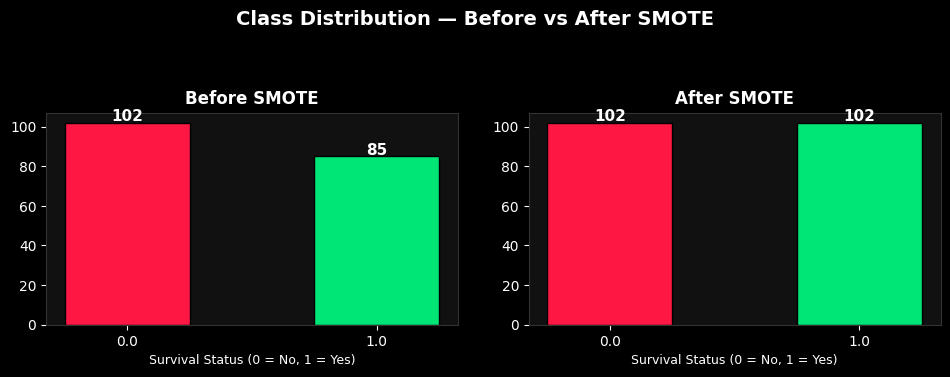


✅ Final dataset shape after SMOTE : (204, 28)


In [28]:
# ============================================================
# CLASS IMBALANCE ADDRESSING
# ============================================================

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# ============================================================
# STEP 0 — Redéfinir cat_cols et num_cols selon l'état actuel du df
# (après suppression des colonnes redondantes)
# ============================================================
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print(f"cat_cols actuels ({len(cat_cols)}) : {cat_cols}")
print(f"num_cols actuels ({len(num_cols)}) : {num_cols}")

# ============================================================
# STEP 1 — Encoder les colonnes catégorielles
# (SMOTE ne fonctionne que sur des données numériques)
# ============================================================
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=['survival_status'])
y = df_encoded['survival_status']

print("\nBefore SMOTE :")
print(y.value_counts())
print(f"Imbalance ratio : {y.value_counts()[0] / y.value_counts()[1]:.2f}x")

# ============================================================
# STEP 2 — Appliquer SMOTE
# ============================================================
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE :")
print(pd.Series(y_resampled).value_counts())

# ============================================================
# STEP 3 — Visualiser avant vs après
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor('#000000')

for ax, (data, title) in zip(axes, [
    (y,           "Before SMOTE"),
    (y_resampled, "After SMOTE")
]):
    counts = pd.Series(data).value_counts()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=['#FF1744', '#00E676'], edgecolor='black', width=0.5)

    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                str(count), ha='center',
                color='white', fontweight='bold', fontsize=11)

    ax.set_title(title, color='white', fontweight='bold', fontsize=12)
    ax.set_xlabel('Survival Status (0 = No, 1 = Yes)', color='white', fontsize=9)
    ax.set_facecolor('#111111')
    ax.tick_params(colors='white')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

plt.suptitle("Class Distribution — Before vs After SMOTE",
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout(pad=2.5)
plt.show()

# ============================================================
# STEP 4 — Reconstruire df_resampled
# ============================================================
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['survival_status'] = y_resampled

print(f"\n✅ Final dataset shape after SMOTE : {df_resampled.shape}")

In [ ]:
# Optimizing Memory Usage

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def optimize_memory(df: pd.DataFrame, verbose: bool = True) -> tuple[pd.DataFrame, float, float]:
    """
    Optimise l'usage mémoire d'un DataFrame de manière intelligente et robuste.
    
    Stratégies appliquées :
      - Entiers   : downcasting vers int8 / int16 / int32 selon la plage de valeurs
      - Flottants : downcasting vers float32 si la précision est préservée
      - Objects   : conversion en 'category' si cardinalité faible (< 50%)
      - Booléens  : conversion en bool (1 bit au lieu de 8)
    
    Args:
        df      : DataFrame à optimiser
        verbose : Afficher le détail colonne par colonne (défaut : True)
    
    Returns:
        df_optimized : DataFrame optimisé
        start_mem    : Mémoire initiale en MB
        end_mem      : Mémoire finale en MB
    """

    # Travailler sur une copie pour ne pas modifier le DataFrame original
    df = df.copy()

    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    changes   = []   # Journal des conversions effectuées

    for col in df.columns:
        col_type     = df[col].dtype
        original_type = str(col_type)

        # --------------------------------------------------------
        # CAS 1 : Colonnes numériques entières
        # --------------------------------------------------------
        if pd.api.types.is_integer_dtype(df[col]):
            try:
                c_min = df[col].min()
                c_max = df[col].max()

                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                # int64 conservé si nécessaire

                changes.append((col, original_type, str(df[col].dtype)))
            except (TypeError, ValueError):
                pass

        # --------------------------------------------------------
        # CAS 2 : Colonnes numériques flottantes
        # --------------------------------------------------------
        elif pd.api.types.is_float_dtype(df[col]):
            try:
                c_min = df[col].min()
                c_max = df[col].max()

                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                # float64 conservé si la plage dépasse float32

                changes.append((col, original_type, str(df[col].dtype)))
            except (TypeError, ValueError):
                pass

        # --------------------------------------------------------
        # CAS 3 : Colonnes booléennes (souvent stockées en int ou object)
        # --------------------------------------------------------
        elif pd.api.types.is_object_dtype(df[col]):
            unique_vals = df[col].dropna().unique()

            # Détection booléen déguisé (ex: '0'/'1', 'True'/'False', 'yes'/'no')
            bool_maps = [
                {'0', '1'}, {'true', 'false'},
                {'yes', 'no'}, {'oui', 'non'}
            ]
            is_bool = any(
                set(str(v).lower() for v in unique_vals) <= bm
                for bm in bool_maps
            )

            try:
                if is_bool:
                    # Convertir en booléen
                    bool_map = {'1': True, '0': False,
                                'true': True, 'false': False,
                                'yes': True, 'no': False,
                                'oui': True, 'non': False}
                    df[col] = df[col].str.lower().map(bool_map).astype('boolean')
                    changes.append((col, original_type, 'boolean'))

                elif len(unique_vals) / len(df[col]) < 0.5:
                    # Faible cardinalité → category (économise beaucoup de mémoire)
                    df[col] = df[col].astype('category')
                    changes.append((col, original_type, 'category'))

            except (TypeError, ValueError, AttributeError):
                pass

        # --------------------------------------------------------
        # CAS 4 : Colonnes déjà en category → conserver
        # --------------------------------------------------------
        elif pd.api.types.is_categorical_dtype(df[col]):
            pass

    end_mem = df.memory_usage(deep=True).sum() / 1024**2

    # --------------------------------------------------------
    # RAPPORT DÉTAILLÉ
    # --------------------------------------------------------
    if verbose:
        print("=" * 55)
        print("        RAPPORT D'OPTIMISATION MÉMOIRE")
        print("=" * 55)
        print(f"  Mémoire initiale  : {start_mem:.4f} MB")
        print(f"  Mémoire finale    : {end_mem:.4f} MB")
        print(f"  Réduction         : {(start_mem - end_mem) / start_mem * 100:.1f}%")
        print("-" * 55)
        print(f"  {'Colonne':<25} {'Avant':<12} {'Après':<12}")
        print("-" * 55)
        for col, before, after in changes:
            marker = "✅" if before != after else "—"
            print(f"  {marker} {col:<23} {before:<12} {after:<12}")
        print("=" * 55)

    return df, start_mem, end_mem


# ============================================================
# APPEL DE LA FONCTION
# ============================================================
df_resampled, start_mem, end_mem = optimize_memory(df_resampled, verbose=True)
df.head(204)


In [30]:
df_resampled.to_csv('../data/bone-marrow-fiinal.csv', index=False)

print(f"✅ Shape sauvegardé : {df_resampled.shape}")

✅ Shape sauvegardé : (204, 28)


In [31]:
import os
print(os.path.abspath('../data/bone-marrow-fiinal.csv'))

c:\Users\user\Documents\GitHub\bone-marrow-transplant-analysis2\data\bone-marrow-fiinal.csv
